# Problem 1

<div style="text-align:center;">
    <img src="Problem1.png" width=600">
</div>

## Part 1
Design by hand a gait that will move the robot forward

<div style="text-align:center;">
    <img src="Problem2.jpeg" width=800">
</div>

In [4]:
import sympy as sp
import numpy as np
from sympy import lambdify, cos, sin, Matrix, simplify

# Helper Functions 
def cross_matrix(vec):
    
    return np.array([[0, -vec[2,0], vec[1,0]],
                   [vec[2,0], 0, -vec[0,0]],
                   [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                   [mat[0,2]], 
                   [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return m
    
def R_z(theta):
    return np.array([[cos(theta), -sin(theta), 0], 
                   [sin(theta),  cos(theta), 0],
                   [0,           0,          1]])

def R_y(theta):
    return np.array([[cos(theta), 0, sin(theta)], 
                   [0,          1, 0],
                   [-sin(theta),0, cos(theta)]])

def R_x(theta):
    return np.array([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta),  cos(theta)]])

def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

# Geometry
t = sp.symbols("t", real=True)

L = sp.symbols("L", real=True)   # body length
d = sp.symbols("d", real=True)   # appendage link length
k = sp.symbols("k", real=True)   # drag coefficient

# Configuration variables
x = sp.Function('x', real=True)(t)
y = sp.Function('y', real=True)(t)
theta = sp.Function('theta', real=True)(t)

alpha1 = sp.Function('alpha1', real=True)(t)
alpha2 = sp.Function('alpha2', real=True)(t)

# q = pose + symmetric shape variables
q = [x, y, theta, alpha1, alpha2]
q_dt = [sp.diff(qq, t) for qq in q]
q_dtdt = [sp.diff(qq, t, t) for qq in q]


# Transformation matrices
# World to body center
T_0b = T(R_z(theta), Matrix([[x], [y], [0]]))

# Body COM
T_b = T_0b

# Appendage joint location at front of body
T_body_to_joint = T(Matrix.eye(3), Matrix([[L/2], [0], [0]]))

# Left link 1 COM
T_l1 = T_0b @ T_body_to_joint @ T(R_z(alpha1), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d/2], [0], [0]]))
       
# Left link 2 COM
T_l2 = T_0b @ T_body_to_joint @ T(R_z(alpha1), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d], [0], [0]])) @ T(R_z(alpha2), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d/2], [0], [0]]))

# Right link 1 COM
# Right side uses negative angle so positive alpha bends clockwise
T_r1 = T_0b @ T_body_to_joint @ T(R_z(-alpha1), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d/2], [0], [0]]))

# Right link 2 COM
T_r2 = T_0b  @ T_body_to_joint @ T(R_z(-alpha1), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d], [0], [0]])) @ T(R_z(-alpha2), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3), Matrix([[d/2], [0], [0]]))

# Body twists
# Vb = T^-1 * Tdot
body_twist_b = T_b.inv() @ sp.diff(T_b, t)
body_twist_l1 = T_l1.inv() @ sp.diff(T_l1, t)
body_twist_l2 = T_l2.inv() @ sp.diff(T_l2, t)
body_twist_r1 = T_r1.inv() @ sp.diff(T_r1, t)
body_twist_r2 = T_r2.inv() @ sp.diff(T_r2, t)

# Twist vectors
v_b = twist2vec(body_twist_b)
v_l1 = twist2vec(body_twist_l1)
v_l2 = twist2vec(body_twist_l2)
v_r1 = twist2vec(body_twist_r1)
v_r2 = twist2vec(body_twist_r2)

# Body Jacobians
J_b = v_b.jacobian(q_dt)
J_l1 = v_l1.jacobian(q_dt)
J_l2 = v_l2.jacobian(q_dt)
J_r1 = v_r1.jacobian(q_dt)
J_r2 = v_r2.jacobian(q_dt)


# Drag matrices
# Body drag matrix, body length L
B_body = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*L**3,     0,   0,      0],
    [0, 0, 0,              k*L, 0,      0],
    [0, 0, 0,              0,   2*k*L,  0],
    [0, 0, 0,              0,   0,      0]
])

# Appendage link drag matrix, link length d
B_link = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*d**3,     0,   0,      0],
    [0, 0, 0,              k*d, 0,      0],
    [0, 0, 0,              0,   2*k*d,  0],
    [0, 0, 0,              0,   0,      0]
])

# Generalized force balance matrix
A = J_b.T  @ B_body @ J_b + J_l1.T @ B_link @ J_l1 + J_l2.T @ B_link @ J_l2 + J_r1.T @ B_link @ J_r1 + J_r2.T @ B_link @ J_r2

A_11 = A[0:3, 0:3]
A_12 = A[0:3, 3:]
A_21 = A[3:, 0:3]
A_22 = A[3:, 3:]

# Local connection matrix
# pose_dot = -A_11^-1 A_12 shape_dot
A_tilde = -A_11.LUsolve(A_12)

# Lambdify
params = [L, d, k]

A_11_lambda = lambdify([t, q, q_dt, params], A_11, "numpy")
A_12_lambda = lambdify([t, q, q_dt, params], A_12, "numpy")
A_tilde_lambda = lambdify([t, q, q_dt, params], A_tilde, "numpy")


def connection_matrix(t_num, q_num, q_dt_num, params_num):
    A11 = A_11_lambda(t_num, q_num, q_dt_num, params_num)
    A12 = A_12_lambda(t_num, q_num, q_dt_num, params_num)
    return -np.linalg.solve(A11, A12)

In [5]:
# To check the zero-angle configuration it should only have a x-direction and zero for both x,y components
test_subs = {
    x: 0,
    y: 0,
    theta: 0,
    alpha1: 0,
    alpha2: 0,
    L: 2,
    d: 1
}

simplify(T_b.subs(test_subs)), simplify(T_l1.subs(test_subs)), simplify(T_l2.subs(test_subs)), simplify(T_r1.subs(test_subs)), simplify(T_r2.subs(test_subs))

(Matrix([
 [1, 0, 0, 0],
 [0, 1, 0, 0],
 [0, 0, 1, 0],
 [0, 0, 0, 1]]),
 Matrix([
 [1, 0, 0, 3/2],
 [0, 1, 0,   0],
 [0, 0, 1,   0],
 [0, 0, 0,   1]]),
 Matrix([
 [1, 0, 0, 5/2],
 [0, 1, 0,   0],
 [0, 0, 1,   0],
 [0, 0, 0,   1]]),
 Matrix([
 [1, 0, 0, 3/2],
 [0, 1, 0,   0],
 [0, 0, 1,   0],
 [0, 0, 0,   1]]),
 Matrix([
 [1, 0, 0, 5/2],
 [0, 1, 0,   0],
 [0, 0, 1,   0],
 [0, 0, 0,   1]]))

Net x displacement: 0.15838455685340302
Net y displacement: 1.0642684725136018e-18
Net theta change: 7.239625399882056e-18


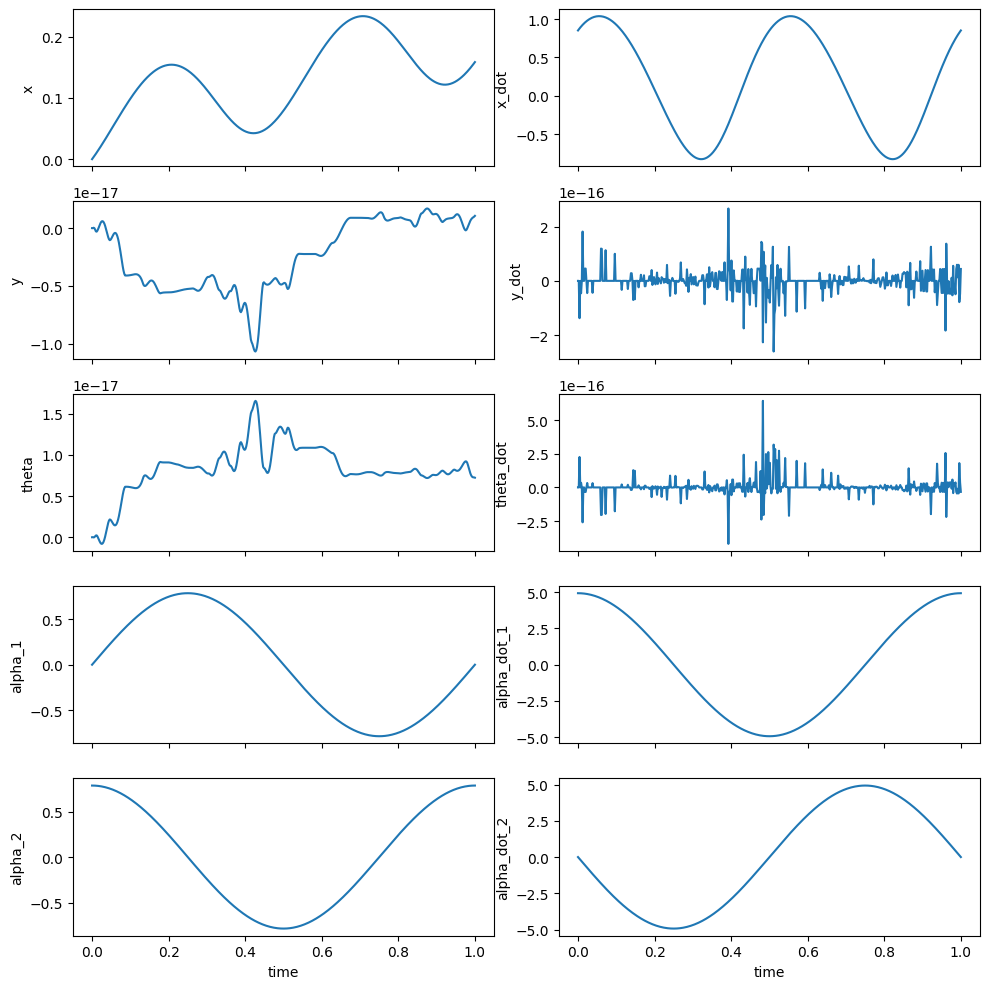

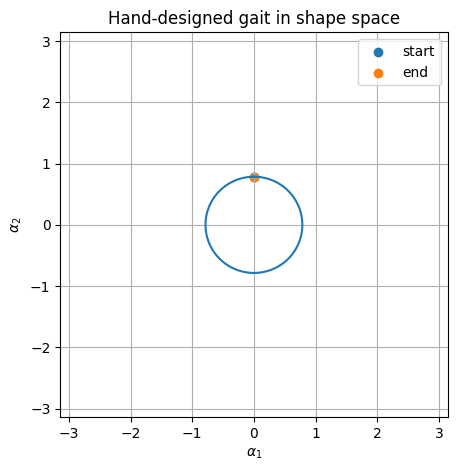

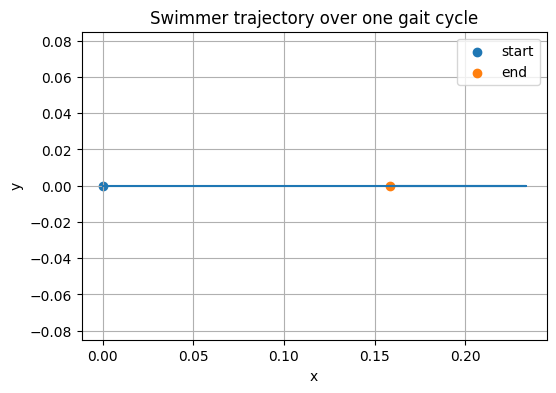

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Part 1: hand-designed gait
# alpha1 = pi/4 sin(2 pi t)
# alpha2 = pi/4 cos(2 pi t)
A_gait = np.pi / 4

def gait(t_num):
    alpha1 = A_gait * np.sin(2*np.pi*t_num)
    alpha2 = A_gait * np.cos(2*np.pi*t_num)

    alpha1_dot = A_gait * 2*np.pi * np.cos(2*np.pi*t_num)
    alpha2_dot = -A_gait * 2*np.pi * np.sin(2*np.pi*t_num)

    return alpha1, alpha2, alpha1_dot, alpha2_dot

# Swimmer dynamics
# z = [x, y, theta]
def swimmer_dynamics(t_num, z, params_num):
    x_num, y_num, theta_num = z

    alpha1, alpha2, alpha1_dot, alpha2_dot = gait(t_num)

    q_num = np.array([
        x_num,
        y_num,
        theta_num,
        alpha1,
        alpha2
    ], dtype=float)

    q_dot_num = np.array([
        0,
        0,
        0,
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    A_tilde_num = np.array(
        A_tilde_lambda(t_num, q_num, q_dot_num, params_num),
        dtype=float
    )

    shape_dot = np.array([
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    pose_dot = A_tilde_num @ shape_dot

    return pose_dot.flatten()

# Simulate one gait cycle
params_num = [1.0, 0.5, 1.0]   # [L, d, k]

z0 = np.array([0.0, 0.0, 0.0])

t_span = (0.0, 1.0)
time = np.linspace(0.0, 1.0, 500)

sol = solve_ivp(
    fun=lambda t_num, z: swimmer_dynamics(t_num, z, params_num),
    t_span=t_span,
    y0=z0,
    t_eval=time,
    rtol=1e-8,
    atol=1e-8
)

x_sol = sol.y[0]
y_sol = sol.y[1]
theta_sol = sol.y[2]

alpha_1_sol = np.zeros_like(time)
alpha_2_sol = np.zeros_like(time)
alpha_1_dot_sol = np.zeros_like(time)
alpha_2_dot_sol = np.zeros_like(time)

x_dot_sol = np.zeros_like(time)
y_dot_sol = np.zeros_like(time)
theta_dot_sol = np.zeros_like(time)

for i, ti in enumerate(time):
    alpha_1_sol[i], alpha_2_sol[i], alpha_1_dot_sol[i], alpha_2_dot_sol[i] = gait(ti)

    zdot = swimmer_dynamics(
        ti,
        np.array([x_sol[i], y_sol[i], theta_sol[i]]),
        params_num
    )

    x_dot_sol[i] = zdot[0]
    y_dot_sol[i] = zdot[1]
    theta_dot_sol[i] = zdot[2]

# Print net motion
print("Net x displacement:", x_sol[-1] - x_sol[0])
print("Net y displacement:", y_sol[-1] - y_sol[0])
print("Net theta change:", theta_sol[-1] - theta_sol[0])

fig = plt.figure(1, figsize=(10, 10))
fig.clf()
ax = fig.subplots(5, 2, sharex=True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')

ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')

ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')

ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha_1')

ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')
ax[4][0].set_xlabel('time')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')

ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')

ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')

ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')

ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
ax[4][1].set_xlabel('time')

plt.tight_layout()


# Shape-space gait plot
plt.figure(10, figsize=(5, 5))
plt.plot(alpha_1_sol, alpha_2_sol)
plt.scatter(alpha_1_sol[0], alpha_2_sol[0], label='start')
plt.scatter(alpha_1_sol[-1], alpha_2_sol[-1], label='end')
plt.gca().axis([-np.pi, np.pi, -np.pi, np.pi])
plt.xlabel(r'$\alpha_1$')
plt.ylabel(r'$\alpha_2$')
plt.title('Hand-designed gait in shape space')
plt.grid(True)
plt.legend()

plt.figure(11, figsize=(6, 4))
plt.plot(x_sol, y_sol)
plt.scatter(x_sol[0], y_sol[0], label='start')
plt.scatter(x_sol[-1], y_sol[-1], label='end')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Swimmer trajectory over one gait cycle')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

## Part 2
Develop a gait generation function using a truncated Fourier series for $\alpha_1$, $\alpha_2$

In [7]:
def fourier_gait(t_num, coeffs, omega=2*np.pi):
    """
    Truncated Fourier series gait for alpha1 and alpha2.

    coeffs format:
    coeffs = {
        "a1_cos": [...],
        "a1_sin": [...],
        "a2_cos": [...],
        "a2_sin": [...]
    }

    Each list has length N.
    """

    a1_cos = np.array(coeffs["a1_cos"])
    a1_sin = np.array(coeffs["a1_sin"])
    a2_cos = np.array(coeffs["a2_cos"])
    a2_sin = np.array(coeffs["a2_sin"])

    N = len(a1_cos)

    alpha1 = 0.0
    alpha2 = 0.0
    alpha1_dot = 0.0
    alpha2_dot = 0.0

    for k in range(1, N + 1):
        alpha1 += a1_cos[k-1]*np.cos(k*omega*t_num) + a1_sin[k-1]*np.sin(k*omega*t_num)
        alpha2 += a2_cos[k-1]*np.cos(k*omega*t_num) + a2_sin[k-1]*np.sin(k*omega*t_num)

        alpha1_dot += -a1_cos[k-1]*k*omega*np.sin(k*omega*t_num) + a1_sin[k-1]*k*omega*np.cos(k*omega*t_num)
        alpha2_dot += -a2_cos[k-1]*k*omega*np.sin(k*omega*t_num) + a2_sin[k-1]*k*omega*np.cos(k*omega*t_num)

    return alpha1, alpha2, alpha1_dot, alpha2_dot

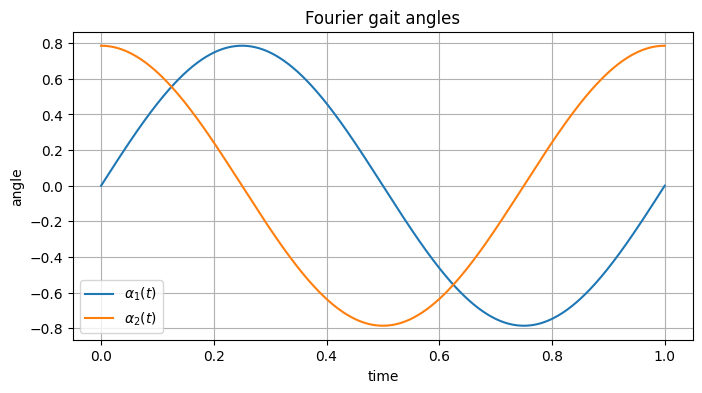

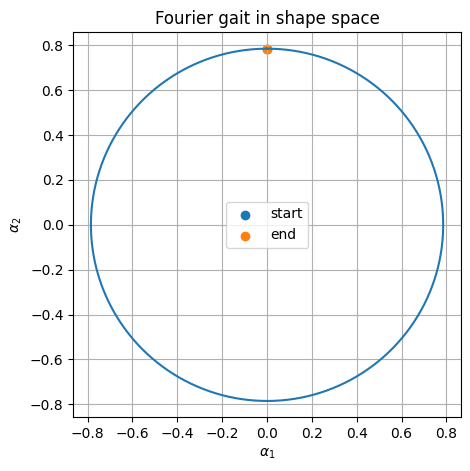

In [8]:
coeffs_test = {
    "a1_cos": [0.0],
    "a1_sin": [np.pi/4],
    "a2_cos": [np.pi/4],
    "a2_sin": [0.0]
}

time = np.linspace(0, 1, 500)

alpha_1_sol = np.zeros_like(time)
alpha_2_sol = np.zeros_like(time)
alpha_1_dot_sol = np.zeros_like(time)
alpha_2_dot_sol = np.zeros_like(time)

for i, ti in enumerate(time):
    alpha_1_sol[i], alpha_2_sol[i], alpha_1_dot_sol[i], alpha_2_dot_sol[i] = fourier_gait(
        ti,
        coeffs_test
    )

plt.figure(figsize=(8, 4))
plt.plot(time, alpha_1_sol, label=r'$\alpha_1(t)$')
plt.plot(time, alpha_2_sol, label=r'$\alpha_2(t)$')
plt.xlabel('time')
plt.ylabel('angle')
plt.title('Fourier gait angles')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(alpha_1_sol, alpha_2_sol)
plt.scatter(alpha_1_sol[0], alpha_2_sol[0], label='start')
plt.scatter(alpha_1_sol[-1], alpha_2_sol[-1], label='end')
plt.xlabel(r'$\alpha_1$')
plt.ylabel(r'$\alpha_2$')
plt.title('Fourier gait in shape space')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.11598016515007362
            Iterations: 10
            Function evaluations: 70
            Gradient evaluations: 10
Optimization success: True
Optimizer message: Optimization terminated successfully
Maximum forward distance: 0.11598016515007362
Optimized coefficients:
[ 0.35        0.35        0.00119419  1.          1.         -0.18419492]
Net x displacement: 0.11598016515007362
Net y displacement: -1.4485792905725488e-17
Net theta change: -2.295064155885607e-17


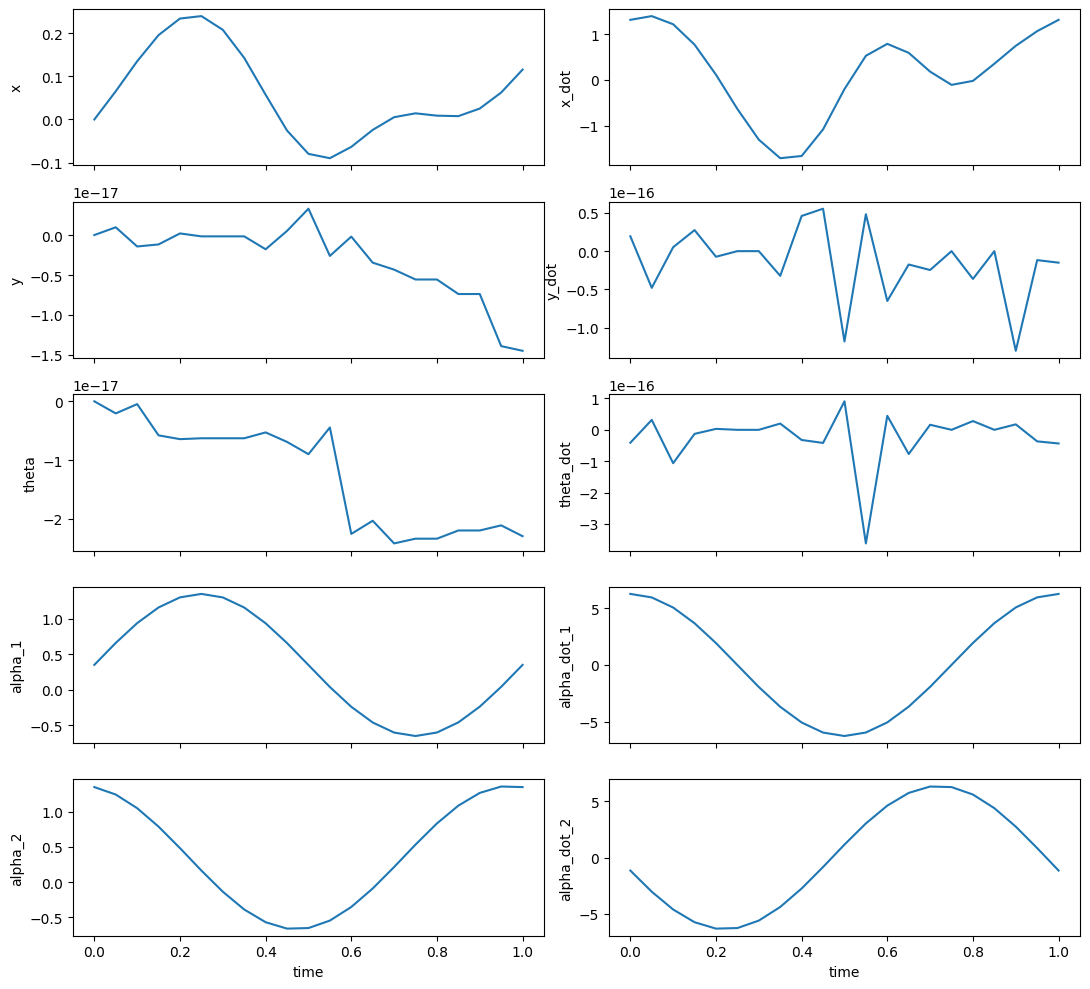

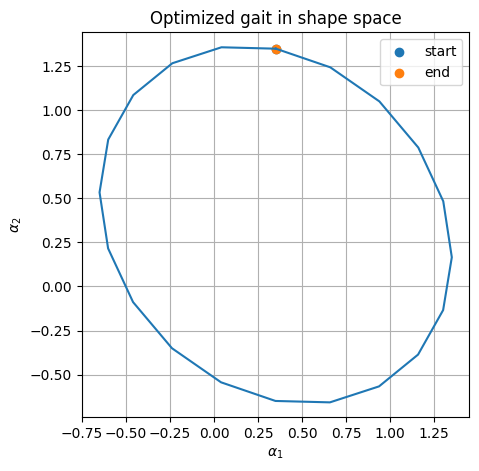

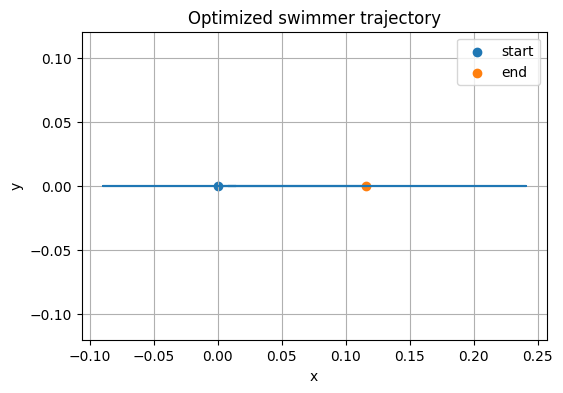

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =====================================================
# 0ptimization for maximum forward distance

N_fourier = 1
params_num = [1.0, 0.5, 1.0]   # [L, d, k]


dt = 1/60
time_opt = np.arange(0.0, 1.0 + dt, dt)

z0 = np.array([0.0, 0.0, 0.0])

# Fourier gait with offsets
# c = [alpha1_offset, alpha2_offset,
#      alpha1_cos, alpha1_sin,
#      alpha2_cos, alpha2_sin]
def fourier_gait_with_offset(t_num, c, omega=2*np.pi):
    a10 = c[0]
    a20 = c[1]

    a1_cos = c[2]
    a1_sin = c[3]
    a2_cos = c[4]
    a2_sin = c[5]

    alpha1 = a10 + a1_cos*np.cos(omega*t_num) + a1_sin*np.sin(omega*t_num)
    alpha2 = a20 + a2_cos*np.cos(omega*t_num) + a2_sin*np.sin(omega*t_num)

    alpha1_dot = -a1_cos*omega*np.sin(omega*t_num) + a1_sin*omega*np.cos(omega*t_num)
    alpha2_dot = -a2_cos*omega*np.sin(omega*t_num) + a2_sin*omega*np.cos(omega*t_num)

    return alpha1, alpha2, alpha1_dot, alpha2_dot

# Dynamics using Fourier gait
def swimmer_dynamics_fourier_offset(t_num, z, c):
    x_num, y_num, theta_num = z

    alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gait_with_offset(t_num, c)

    q_num = np.array([
        x_num,
        y_num,
        theta_num,
        alpha1,
        alpha2
    ], dtype=float)

    q_dot_num = np.array([
        0.0,
        0.0,
        0.0,
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    A_tilde_num = np.array(
        A_tilde_lambda(t_num, q_num, q_dot_num, params_num),
        dtype=float
    )

    shape_dot = np.array([
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    pose_dot = A_tilde_num @ shape_dot

    return pose_dot.flatten()

# Euler simulation over one cycle
def simulate_one_cycle(c, dt=1/60):
    z = z0.copy()

    x_hist = []
    y_hist = []
    theta_hist = []

    alpha1_hist = []
    alpha2_hist = []
    alpha1dot_hist = []
    alpha2dot_hist = []

    xdot_hist = []
    ydot_hist = []
    thetadot_hist = []

    time_hist = np.arange(0.0, 1.0 + dt, dt)

    for ti in time_hist:
        alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gait_with_offset(ti, c)

        zdot = swimmer_dynamics_fourier_offset(ti, z, c)

        x_hist.append(z[0])
        y_hist.append(z[1])
        theta_hist.append(z[2])

        alpha1_hist.append(alpha1)
        alpha2_hist.append(alpha2)
        alpha1dot_hist.append(alpha1_dot)
        alpha2dot_hist.append(alpha2_dot)

        xdot_hist.append(zdot[0])
        ydot_hist.append(zdot[1])
        thetadot_hist.append(zdot[2])

        z = z + dt * zdot

        if not np.all(np.isfinite(z)):
            break

    return {
        "time": np.array(time_hist[:len(x_hist)]),
        "x": np.array(x_hist),
        "y": np.array(y_hist),
        "theta": np.array(theta_hist),
        "alpha1": np.array(alpha1_hist),
        "alpha2": np.array(alpha2_hist),
        "alpha1_dot": np.array(alpha1dot_hist),
        "alpha2_dot": np.array(alpha2dot_hist),
        "x_dot": np.array(xdot_hist),
        "y_dot": np.array(ydot_hist),
        "theta_dot": np.array(thetadot_hist),
    }

# Objective: maximize forward x distance
def objective_max_forward(c):
    try:
        sim = simulate_one_cycle(c, dt=dt)

        if len(sim["x"]) < 5:
            return 1e6

        net_x = sim["x"][-1] - sim["x"][0]

        if not np.isfinite(net_x):
            return 1e6

        return -net_x

    except Exception:
        return 1e6

# Initial guess
# alpha1 = 0.6 + pi/6 sin(2pi t)
# alpha2 = 0.6 + pi/6 cos(2pi t)
c0 = np.array([
    0.6,        # alpha1 offset
    0.6,        # alpha2 offset
    0.0,        # alpha1 cos
    np.pi/6,    # alpha1 sin
    np.pi/6,    # alpha2 cos
    0.0         # alpha2 sin
], dtype=float)

# Bounds to make optimization faster and avoid singularities
bounds = [
    (0.35, 1.2),      # alpha1 offset
    (0.35, 1.2),      # alpha2 offset
    (-1.0, 1.0),      # alpha1 cos
    (-1.0, 1.0),      # alpha1 sin
    (-1.0, 1.0),      # alpha2 cos
    (-1.0, 1.0),      # alpha2 sin
]

# Run optimizer
result_forward = minimize(
    objective_max_forward,
    c0,
    method="SLSQP",
    bounds=bounds,
    options={
        "maxiter": 20,
        "ftol": 1e-4,
        "disp": True
    }
)

c_opt_forward = result_forward.x

print("Optimization success:", result_forward.success)
print("Optimizer message:", result_forward.message)
print("Maximum forward distance:", -result_forward.fun)
print("Optimized coefficients:")
print(c_opt_forward)

# Simulate optimized gait
sim = simulate_one_cycle(c_opt_forward, dt=dt)

time = sim["time"]
x_sol = sim["x"]
y_sol = sim["y"]
theta_sol = sim["theta"]

alpha_1_sol = sim["alpha1"]
alpha_2_sol = sim["alpha2"]

alpha_1_dot_sol = sim["alpha1_dot"]
alpha_2_dot_sol = sim["alpha2_dot"]

x_dot_sol = sim["x_dot"]
y_dot_sol = sim["y_dot"]
theta_dot_sol = sim["theta_dot"]

print("Net x displacement:", x_sol[-1] - x_sol[0])
print("Net y displacement:", y_sol[-1] - y_sol[0])
print("Net theta change:", theta_sol[-1] - theta_sol[0])


# Plotting states and velocities
fig = plt.figure(1, figsize=(11, 10))
fig.clf()
ax = fig.subplots(5, 2, sharex=True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')

ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')

ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')

ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha_1')

ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')
ax[4][0].set_xlabel('time')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')

ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')

ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')

ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')

ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
ax[4][1].set_xlabel('time')

plt.tight_layout()

# Shape-space plot
plt.figure(2, figsize=(5, 5))
plt.plot(alpha_1_sol, alpha_2_sol)
plt.scatter(alpha_1_sol[0], alpha_2_sol[0], label='start')
plt.scatter(alpha_1_sol[-1], alpha_2_sol[-1], label='end')
plt.xlabel(r'$\alpha_1$')
plt.ylabel(r'$\alpha_2$')
plt.title('Optimized gait in shape space')
plt.grid(True)
plt.axis('equal')
plt.legend()

# XY trajectory plot
plt.figure(3, figsize=(6, 4))
plt.plot(x_sol, y_sol)
plt.scatter(x_sol[0], y_sol[0], label='start')
plt.scatter(x_sol[-1], y_sol[-1], label='end')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Optimized swimmer trajectory')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =====================================================
# Faster Minimum COT optimization
# =====================================================

dt = 1/60
params_num = [1.0, 0.5, 1.0]   # [L, d, k]
z0 = np.array([0.0, 0.0, 0.0])


# =====================================================
# Fourier gait with offsets
# c = [alpha1_offset, alpha2_offset,
#      alpha1_cos, alpha1_sin,
#      alpha2_cos, alpha2_sin]
# =====================================================

def fourier_gait_with_offset(t_num, c, omega=2*np.pi):
    a10 = c[0]
    a20 = c[1]

    a1_cos = c[2]
    a1_sin = c[3]
    a2_cos = c[4]
    a2_sin = c[5]

    alpha1 = a10 + a1_cos*np.cos(omega*t_num) + a1_sin*np.sin(omega*t_num)
    alpha2 = a20 + a2_cos*np.cos(omega*t_num) + a2_sin*np.sin(omega*t_num)

    alpha1_dot = -a1_cos*omega*np.sin(omega*t_num) + a1_sin*omega*np.cos(omega*t_num)
    alpha2_dot = -a2_cos*omega*np.sin(omega*t_num) + a2_sin*omega*np.cos(omega*t_num)

    return alpha1, alpha2, alpha1_dot, alpha2_dot


# =====================================================
# Swimmer dynamics
# Requires A_tilde_lambda from your previous symbolic code
# =====================================================

def swimmer_dynamics_fourier_offset(t_num, z, c):
    x_num, y_num, theta_num = z

    alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gait_with_offset(t_num, c)

    q_num = np.array([
        x_num,
        y_num,
        theta_num,
        alpha1,
        alpha2
    ], dtype=float)

    q_dot_num = np.array([
        0.0,
        0.0,
        0.0,
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    A_tilde_num = np.array(
        A_tilde_lambda(t_num, q_num, q_dot_num, params_num),
        dtype=float
    )

    shape_dot = np.array([
        alpha1_dot,
        alpha2_dot
    ], dtype=float)

    pose_dot = A_tilde_num @ shape_dot

    return pose_dot.flatten()


# =====================================================
# Fast Euler simulation over one gait cycle
# =====================================================

def simulate_one_cycle(c, dt=1/20):
    z = z0.copy()

    time_hist = np.arange(0.0, 1.0 + dt, dt)

    x_hist = []
    y_hist = []
    theta_hist = []

    alpha1_hist = []
    alpha2_hist = []
    alpha1dot_hist = []
    alpha2dot_hist = []

    xdot_hist = []
    ydot_hist = []
    thetadot_hist = []

    for ti in time_hist:
        alpha1, alpha2, alpha1_dot, alpha2_dot = fourier_gait_with_offset(ti, c)

        zdot = swimmer_dynamics_fourier_offset(ti, z, c)

        x_hist.append(z[0])
        y_hist.append(z[1])
        theta_hist.append(z[2])

        alpha1_hist.append(alpha1)
        alpha2_hist.append(alpha2)
        alpha1dot_hist.append(alpha1_dot)
        alpha2dot_hist.append(alpha2_dot)

        xdot_hist.append(zdot[0])
        ydot_hist.append(zdot[1])
        thetadot_hist.append(zdot[2])

        z = z + dt * zdot

        if not np.all(np.isfinite(z)):
            break

    n = len(x_hist)

    return {
        "time": np.array(time_hist[:n]),
        "x": np.array(x_hist),
        "y": np.array(y_hist),
        "theta": np.array(theta_hist),
        "alpha1": np.array(alpha1_hist),
        "alpha2": np.array(alpha2_hist),
        "alpha1_dot": np.array(alpha1dot_hist),
        "alpha2_dot": np.array(alpha2dot_hist),
        "x_dot": np.array(xdot_hist),
        "y_dot": np.array(ydot_hist),
        "theta_dot": np.array(thetadot_hist),
    }


# =====================================================
# COT objective
# effort proxy = integral(alpha1_dot^2 + alpha2_dot^2)
# COT = effort / net forward distance
# =====================================================

def objective_min_COT(c):
    try:
        sim = simulate_one_cycle(c, dt=dt)

        if len(sim["x"]) < 5:
            return 1e6

        net_x = sim["x"][-1] - sim["x"][0]

        # Reject backward or tiny forward motion immediately
        if net_x <= 0.01:
            return 1e6

        alpha1_dot = sim["alpha1_dot"]
        alpha2_dot = sim["alpha2_dot"]

        # Faster effort approximation
        effort = dt * np.sum(alpha1_dot**2 + alpha2_dot**2)

        COT = effort / net_x

        if not np.isfinite(COT):
            return 1e6

        # Reject very inefficient gaits
        if COT > 200:
            return 1e6

        return COT

    except Exception:
        return 1e6


# =====================================================
# Initial guess
# Best option: start from your max-forward optimized coefficients
# Requires c_opt_forward from previous optimization
# =====================================================

try:
    c0_COT = c_opt_forward.copy()
except NameError:
    c0_COT = np.array([
        0.6,
        0.6,
        0.0,
        -np.pi/6,
        np.pi/6,
        0.0
    ], dtype=float)


# =====================================================
# Bounds
# Smaller bounds help COT optimization finish faster
# =====================================================

bounds_COT = [
    (0.4, 0.9),      # alpha1 offset
    (0.4, 0.9),      # alpha2 offset
    (-0.7, 0.7),     # alpha1 cos
    (-0.7, 0.7),     # alpha1 sin
    (-0.7, 0.7),     # alpha2 cos
    (-0.7, 0.7),     # alpha2 sin
]

# Make sure c0 is inside bounds
c0_COT = np.array([
    np.clip(c0_COT[i], bounds_COT[i][0], bounds_COT[i][1])
    for i in range(len(c0_COT))
], dtype=float)


# =====================================================
# Run COT optimization
# =====================================================

result_COT = minimize(
    objective_min_COT,
    c0_COT,
    method="SLSQP",
    bounds=bounds_COT,
    options={
        "maxiter": 10,
        "ftol": 1e-3,
        "disp": True
    }
)

c_opt_COT = result_COT.x

print("COT optimization success:", result_COT.success)
print("Optimizer message:", result_COT.message)
print("Minimum COT:", result_COT.fun)
print("Optimized COT coefficients:")
print(c_opt_COT)


# =====================================================
# Simulate optimized COT gait
# =====================================================

sim_COT = simulate_one_cycle(c_opt_COT, dt=dt)

time = sim_COT["time"]
x_sol = sim_COT["x"]
y_sol = sim_COT["y"]
theta_sol = sim_COT["theta"]

alpha_1_sol = sim_COT["alpha1"]
alpha_2_sol = sim_COT["alpha2"]

alpha_1_dot_sol = sim_COT["alpha1_dot"]
alpha_2_dot_sol = sim_COT["alpha2_dot"]

x_dot_sol = sim_COT["x_dot"]
y_dot_sol = sim_COT["y_dot"]
theta_dot_sol = sim_COT["theta_dot"]

net_x = x_sol[-1] - x_sol[0]
net_y = y_sol[-1] - y_sol[0]
net_theta = theta_sol[-1] - theta_sol[0]

effort = dt * np.sum(alpha_1_dot_sol**2 + alpha_2_dot_sol**2)

print("Net x displacement:", net_x)
print("Net y displacement:", net_y)
print("Net theta change:", net_theta)
print("Effort:", effort)

if net_x <= 1e-5:
    print("Invalid COT: gait did not move forward.")
else:
    COT = effort / net_x
    print("Cost of Transport:", COT)

print("max |alpha1|:", np.max(np.abs(alpha_1_sol)))
print("max |alpha2|:", np.max(np.abs(alpha_2_sol)))
print("min |alpha1|:", np.min(np.abs(alpha_1_sol)))
print("min |alpha2|:", np.min(np.abs(alpha_2_sol)))


# =====================================================
# Plot states and velocities
# =====================================================

fig = plt.figure(4, figsize=(11, 10))
fig.clf()
ax = fig.subplots(5, 2, sharex=True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')

ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')

ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')

ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha_1')

ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')
ax[4][0].set_xlabel('time')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')

ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')

ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')

ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')

ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
ax[4][1].set_xlabel('time')

plt.tight_layout()


# =====================================================
# Shape-space plot
# =====================================================

plt.figure(5, figsize=(5, 5))
plt.plot(alpha_1_sol, alpha_2_sol)
plt.scatter(alpha_1_sol[0], alpha_2_sol[0], label='start')
plt.scatter(alpha_1_sol[-1], alpha_2_sol[-1], label='end')
plt.xlabel(r'$\alpha_1$')
plt.ylabel(r'$\alpha_2$')
plt.title('Minimum COT gait in shape space')
plt.grid(True)
plt.axis('equal')
plt.legend()


# =====================================================
# XY trajectory plot
# =====================================================

plt.figure(6, figsize=(6, 4))
plt.plot(x_sol, y_sol)
plt.scatter(x_sol[0], y_sol[0], label='start')
plt.scatter(x_sol[-1], y_sol[-1], label='end')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Minimum COT swimmer trajectory')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.show()